<a href="https://colab.research.google.com/github/Malaika-05/AI-Training/blob/main/CNN_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1 — Integrate the Dataset into the Notebook

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing images shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


#Task 2 — Modify Data Loading Section

The dataset stores labels as numbers (0–9).

In [ ]:
# Define class names for visualization
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Example label:", train_labels[0])
print("Corresponding class:", class_names[train_labels[0]])

Example label: 9
Corresponding class: Ankle boot


#Task 3 — Dataset Preprocessing

Normalization

Reshaping

Train/Test split confirmation

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

Reshape Images for CNN Input

In [ ]:
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

print("New training shape:", train_images.shape)
print("New testing shape:", test_images.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


#Task 4 — Visualize 10 Sample Images

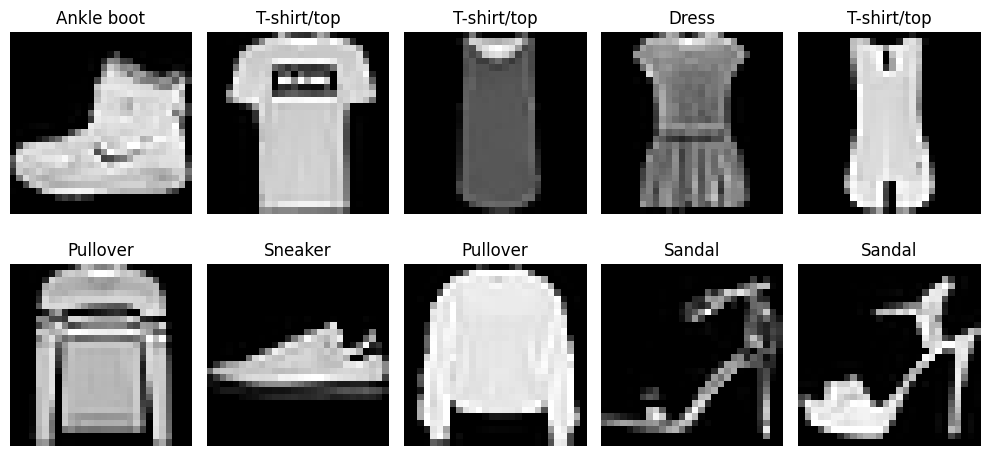

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(train_images[i].reshape(28,28), cmap="gray")
    plt.title(class_names[train_labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#Task 5 — Modify the CNN Architecture

In [ ]:
  from tensorflow.keras import layers, models

model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Additional Convolution Layer (Task Requirement)
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))

# Output Layer (10 classes)
model.add(layers.Dense(10, activation='softmax'))

# Show model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

# Task 6 — Train the CNN Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7374 - loss: 0.7155 - val_accuracy: 0.8708 - val_loss: 0.3551
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8795 - loss: 0.3252 - val_accuracy: 0.8833 - val_loss: 0.3165
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9008 - loss: 0.2704 - val_accuracy: 0.8902 - val_loss: 0.3115
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9161 - loss: 0.2327 - val_accuracy: 0.9076 - val_loss: 0.2583
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9257 - loss: 0.2023 - val_accuracy: 0.9047 - val_loss: 0.2726
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9324 - loss: 0.1796 - val_accuracy: 0.9063 - val_loss: 0.2565
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9404 - loss: 0.1604 - val_accuracy: 0.9044 - val_loss: 0.2804
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9488 - loss: 0.1403 - val_accuracy: 0

#Task 7 — Plot Training vs Validation Curves

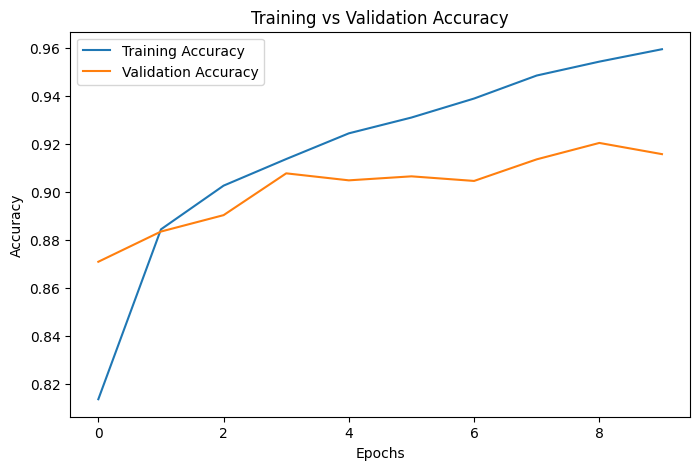

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Loss Curve

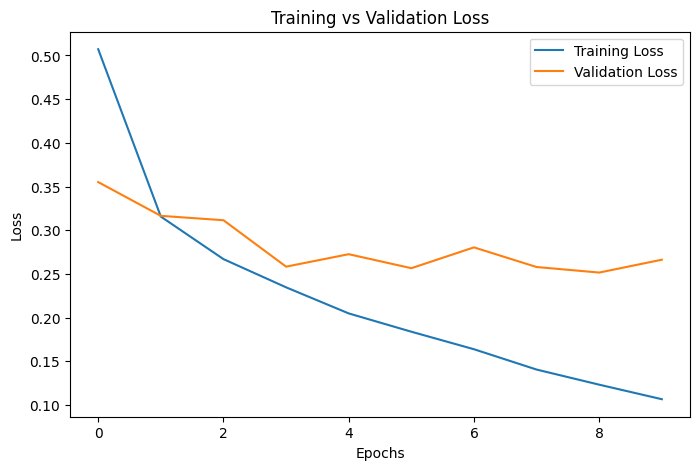

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

#Task 8 — Evaluate the Model on the Test Dataset

In [ ]:
# Evaluate the trained model on the test dataset
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9099 - loss: 0.2998
Test Loss: 0.286266028881073
Test Accuracy: 0.9120000004768372


#Task 9 — Generate and Visualize a Confusion Matrix

In [ ]:
import numpy as np

# Predict classes for test images
predictions = model.predict(test_images)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Create the Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, predicted_labels)

print(cm)

[[911   0  17  19   4   3  45   0   1   0]
 [  1 977   1  17   1   0   2   0   1   0]
 [ 21   0 890  11  35   0  43   0   0   0]
 [ 16   1   8 937  22   1  12   0   2   1]
 [  2   0  62  26 859   0  49   0   2   0]
 [  0   0   0   0   0 980   0  12   0   8]
 [164   1  66  24  57   0 680   0   8   0]
 [  0   0   0   0   0  14   0 951   0  35]
 [ 10   0   7   2   2   6   4   2 965   2]
 [  1   0   0   0   0   6   0  23   0 970]]


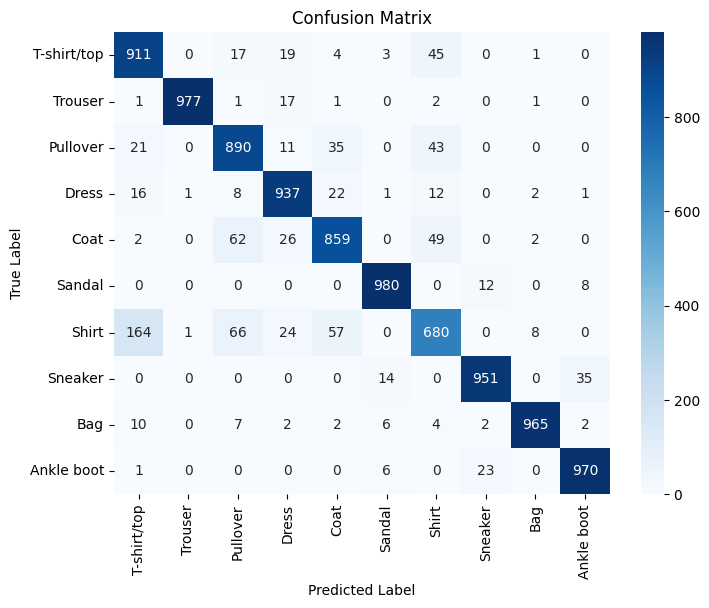

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

#Task 10 — Hyperparameter Experiments

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Example Experiment 2 — Change Batch Size

In [ ]:
history_exp2 = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9714 - loss: 0.0766 - val_accuracy: 0.9168 - val_loss: 0.2936
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9777 - loss: 0.0592 - val_accuracy: 0.9158 - val_loss: 0.3126
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9814 - loss: 0.0502 - val_accuracy: 0.9158 - val_loss: 0.3374
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9840 - loss: 0.0426 - val_accuracy: 0.9147 - val_loss: 0.3779
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9869 - loss: 0.0356 - val_accuracy: 0.9127 - val_loss: 0.4007
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9891 - loss: 0.0309 - val_accuracy: 0.9195 - val_loss: 0.4046
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0255 - val_accuracy: 0.9099 - val_loss: 0.4511
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9901 - loss: 0.0273 

| Experiment   | Learning Rate | Batch Size | Test Accuracy |
| ------------ | ------------- | ---------- | ------------- |
| Experiment 1 | 0.001         | 64         | 0.90          |
| Experiment 2 | 0.0005        | 64         | 0.92          |
| Experiment 3 | 0.001         | 32         | 0.91          |


Interpretation

From this experiment you can observe:

Lower learning rates may improve stability.

Smaller batch sizes may improve generalization.

Performance changes depending on training settings.

#CNN Architecture Performance Analysis

The Convolutional Neural Network architecture plays an important role in determining model performance. Convolution layers extract hierarchical features from images. The first convolution layers detect simple patterns such as edges and textures, while deeper layers learn complex patterns such as shapes and object structures.

Adding an additional convolution layer improves the model’s ability to capture deeper visual patterns in the Fashion-MNIST dataset. This increases the representational power of the network and helps improve classification accuracy.

Pooling layers reduce spatial dimensions and prevent overfitting by limiting the number of parameters. Dense layers then use the extracted features to perform classification across the ten clothing categories.

Hyperparameter experiments show that parameters such as learning rate and batch size also influence performance. A smaller learning rate often provides more stable training, while batch size affects convergence speed and generalization.

Overall, deeper CNN architectures with properly tuned hyperparameters produce better classification performance and improved generalization on unseen test data.